# Proyek AMBA: Exploratory Data Analysis & Point-in-Time Feature Engineering

Dokumen rujukan:
- `AMBA-kamus-variabel.md`
- `AMBANG-panduan-api-sectors.md`

## Tujuan Notebook
1. **Audit & Eksplorasi Data Mentah (EDA)**: Menilai distribusi, kelengkapan, dan karakteristik seluruh variabel mentah dari Sectors API (`quarterly_financials`, `daily_transaction`, `free_float_snapshot`, `company_overview`, `stock_suspensions`).
2. **Taksonomi Suspensi BEI & Pembentukan Label Target**: Mengklasifikasikan alasan suspensi historis ke dalam taksonomi Kategori A (volatilitas kenaikan/cooling down), Kategori B (penurunan signifikan), dan Kategori C (masalah fundamental/kepatuhan/kelangsungan usaha). Kategori C adalah dasar pembentukan label `is_event_90d`.
3. **Point-in-Time Feature Engineering (Anti Data-Leakage)**: Menyelaraskan seluruh observasi temporal dengan titik potong $T_0$ (`as_of_date`), memastikan fitur dihitung hanya dari informasi historis sebelum atau tepat pada $T_0$, dan melacak `feature_max_source_date`.
4. **Sintesis Unified Dataset**: Menggabungkan variabel identitas, variabel mentah laporan keuangan dan pasar, variabel struktur kepemilikan, seluruh 11 indikator risiko turunan, serta label target ke dalam **satu DataFrame terpadu siap pemodelan**.

In [1]:
# 1. Setup & Inisialisasi Environment
import os
import sys
import warnings
from datetime import date, datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Pastikan path root proyek terdaftar secara robust
cwd = os.getcwd()
if os.path.exists(os.path.join(cwd, "sectors_fetcher")):
    project_root = cwd
elif os.path.exists(os.path.join(cwd, "..", "..", "sectors_fetcher")):
    project_root = os.path.abspath(os.path.join(cwd, "..", ".."))
elif os.path.exists(os.path.join(cwd, "..", "sectors_fetcher")):
    project_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    project_root = os.path.abspath(os.path.join(cwd, "..", ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from sectors_fetcher import config
from sectors_fetcher.storage.supabase_client import SupabaseStorage

# Konfigurasi visualisasi
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

print("Environment siap. Project root:", project_root)

Environment siap. Project root: C:\Users\Yosua Triantara\Documents\Project\Ambang


In [2]:
# 2. Ingesti Data Mentah dari Database Supabase
storage = SupabaseStorage()

print("Mengambil tabel mentah dari Supabase...")
df_qf = pd.DataFrame(storage.select_all("quarterly_financials"))
df_dt = pd.DataFrame(storage.select_all("daily_transaction"))
df_ff = pd.DataFrame(storage.select_all("free_float_snapshot"))
df_sus = pd.DataFrame(storage.select_all("stock_suspensions"))
df_co = pd.DataFrame(storage.select_all("company_overview"))

print(f"1. quarterly_financials  : {df_qf.shape[0]} baris, {df_qf.shape[1]} kolom")
print(f"2. daily_transaction     : {df_dt.shape[0]} baris, {df_dt.shape[1]} kolom")
print(f"3. free_float_snapshot   : {df_ff.shape[0]} baris, {df_ff.shape[1]} kolom")
print(f"4. stock_suspensions     : {df_sus.shape[0]} baris, {df_sus.shape[1]} kolom")
print(f"5. company_overview      : {df_co.shape[0]} baris, {df_co.shape[1]} kolom")

Mengambil tabel mentah dari Supabase...


1. quarterly_financials  : 76 baris, 12 kolom
2. daily_transaction     : 1185 baris, 7 kolom
3. free_float_snapshot   : 2883 baris, 6 kolom
4. stock_suspensions     : 591 baris, 6 kolom
5. company_overview      : 19 baris, 7 kolom


---
## 3. Exploratory Data Analysis (EDA)

Pada tahap ini, kita mengeksplorasi setiap entitas data mentah:
- Profil emiten dan papan pencatatan
- Metrik fundamental laporan keuangan kuartalan
- Dinamika transaksi harian, likuiditas, dan volatilitas
- Taksonomi alasan suspensi IDX (kategori A, B, C)

=== Ringkasan Emiten Cakupan ===
 symbol                           company_name                 sector                             sub_sector        board
BBCA.JK              PT Bank Central Asia Tbk.             Financials                                  Banks         Main
TLKM.JK      PT Telkom Indonesia (Persero) Tbk        Infrastructures                      Telecommunication         Main
ASII.JK                Astra International Tbk            Industrials                  Multi-sector Holdings         Main
AMMN.JK    PT Amman Mineral Internasional Tbk.        Basic Materials                        Basic Materials         Main
IMPC.JK         PT Impack Pratama Industri Tbk            Industrials                       Industrial Goods         Main
AADI.JK         PT Adaro Andalan Indonesia Tbk                 Energy                        Oil, Gas & Coal         Main
MGLV.JK            PT Panca Anugrah Wisesa Tbk     Consumer Cyclicals                        Household Goods Acce

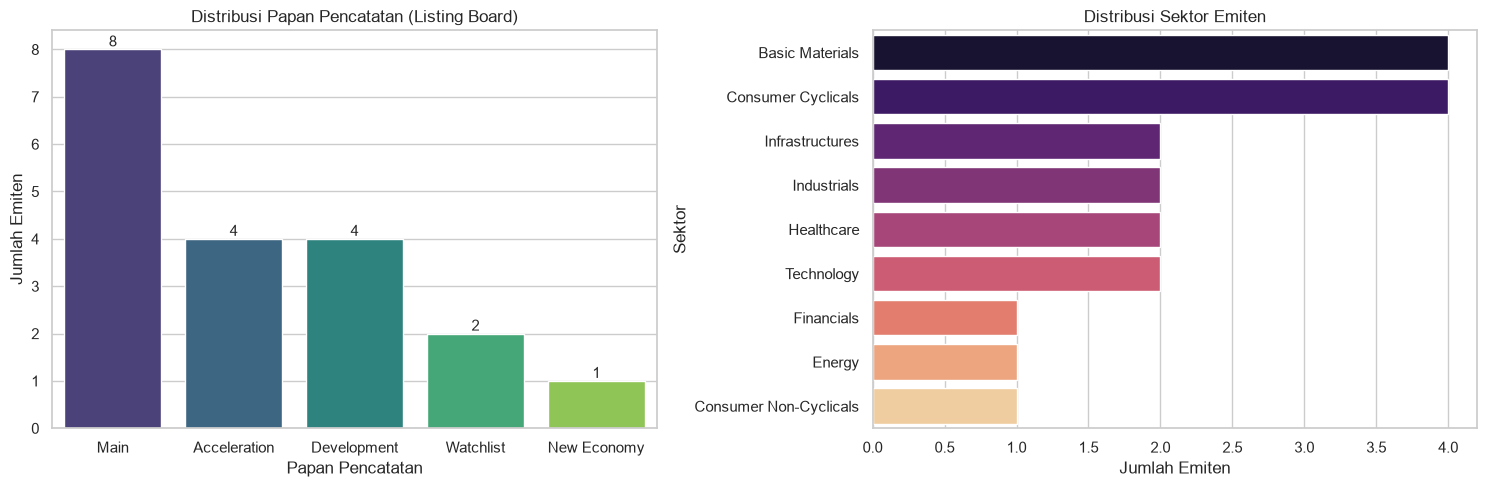

In [3]:
# 3.1 Profil Emiten dan Papan Pencatatan (Board)
print("=== Ringkasan Emiten Cakupan ===")
display_cols = ["symbol", "company_name", "sector", "sub_sector", "board"]
print(df_co[display_cols].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribusi Papan Pencatatan
sns.countplot(
    data=df_co, 
    x="board", 
    order=df_co["board"].value_counts().index, 
    ax=axes[0], 
    palette="viridis"
)
axes[0].set_title("Distribusi Papan Pencatatan (Listing Board)")
axes[0].set_xlabel("Papan Pencatatan")
axes[0].set_ylabel("Jumlah Emiten")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="center", xytext=(0, 5), textcoords="offset points")

# Distribusi Sektor
sns.countplot(
    data=df_co, 
    y="sector", 
    order=df_co["sector"].value_counts().index, 
    ax=axes[1], 
    palette="magma"
)
axes[1].set_title("Distribusi Sektor Emiten")
axes[1].set_xlabel("Jumlah Emiten")
axes[1].set_ylabel("Sektor")

plt.tight_layout()
plt.show()

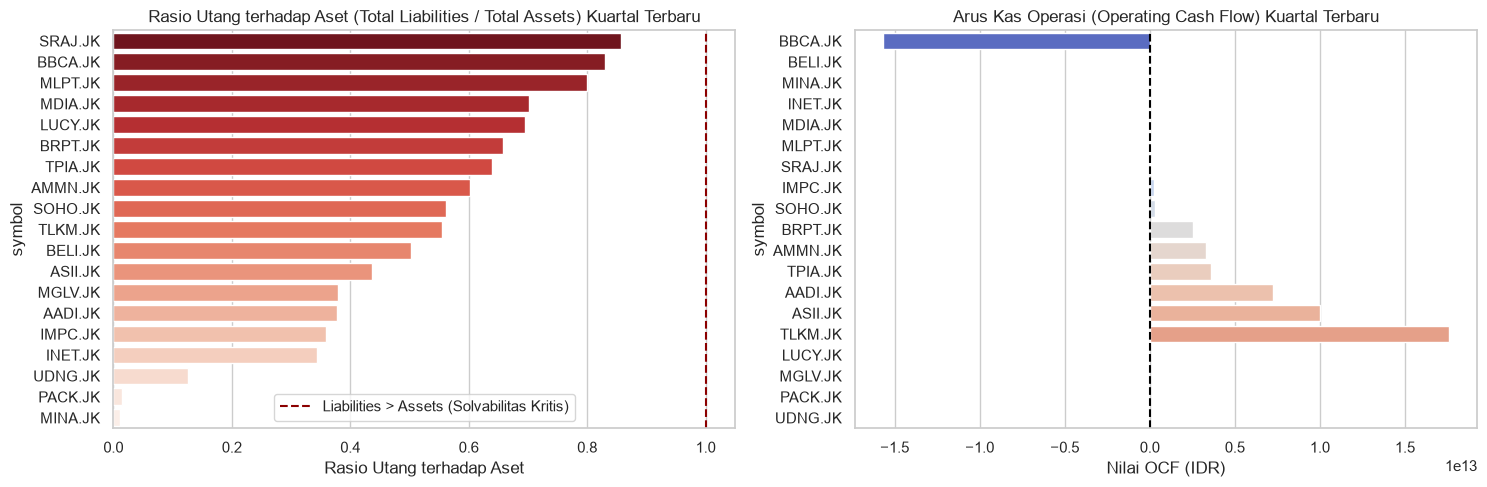

Jumlah emiten dengan ekuitas negatif: 0 emiten
Jumlah emiten dengan OCF negatif pada kuartal terbaru: 2 emiten


In [4]:
# 3.2 Analisis Laporan Keuangan Kuartalan (Fundamental Health)
df_qf["report_date"] = pd.to_datetime(df_qf["report_date"])
num_cols = ["revenue", "earnings", "total_equity", "total_liabilities", "total_assets", "total_debt", "operating_cash_flow", "free_cash_flow"]
for col in num_cols:
    df_qf[col] = pd.to_numeric(df_qf[col], errors="coerce")

# Hitung Debt-to-Assets (Leverage) dan ekuitas negatif
df_qf["debt_to_assets"] = df_qf["total_liabilities"] / df_qf["total_assets"]
df_qf["is_negative_equity"] = (df_qf["total_equity"] < 0).astype(int)
df_qf["is_negative_ocf"] = (df_qf["operating_cash_flow"] < 0).astype(int)

# Tampilkan ringkasan statistik per emiten pada kuartal terbaru
latest_qf = df_qf.sort_values("report_date").groupby("symbol").last().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot Debt-to-Assets Ratio
sns.barplot(
    data=latest_qf.sort_values("debt_to_assets", ascending=False),
    x="debt_to_assets",
    y="symbol",
    ax=axes[0],
    palette="Reds_r"
)
axes[0].axvline(1.0, color="darkred", linestyle="--", label="Liabilities > Assets (Solvabilitas Kritis)")
axes[0].set_title("Rasio Utang terhadap Aset (Total Liabilities / Total Assets) Kuartal Terbaru")
axes[0].set_xlabel("Rasio Utang terhadap Aset")
axes[0].legend()

# Arus Kas Operasi (OCF) Kuartal Terbaru
sns.barplot(
    data=latest_qf.sort_values("operating_cash_flow"),
    x="operating_cash_flow",
    y="symbol",
    ax=axes[1],
    palette="coolwarm"
)
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Arus Kas Operasi (Operating Cash Flow) Kuartal Terbaru")
axes[1].set_xlabel("Nilai OCF (IDR)")

plt.tight_layout()
plt.show()

print(f"Jumlah emiten dengan ekuitas negatif: {latest_qf['is_negative_equity'].sum()} emiten")
print(f"Jumlah emiten dengan OCF negatif pada kuartal terbaru: {latest_qf['is_negative_ocf'].sum()} emiten")

=== Ringkasan Likuiditas & Volatilitas (90 Hari Terakhir) ===
 symbol  total_days  zero_vol_days  at_floor_days   avg_volume  volatility  min_close  max_close  last_close  pct_zero_volume
MDIA.JK          63              7              0 3.481722e+08    0.089460         56        280         197        11.111111
MLPT.JK          63              0              0 1.415973e+07    0.081824        655       1925        1160         0.000000
LUCY.JK          63              1              0 4.940910e+07    0.073136        224       1670         334         1.587302
UDNG.JK          63              1              0 3.294751e+06    0.062627        486       1875         486         1.587302
INET.JK          63              0              0 3.687278e+08    0.055368        181        366         316         0.000000
BELI.JK          62              0              0 1.405803e+06    0.052196        250        406         296         0.000000
SOHO.JK          62              0              0 1.8268

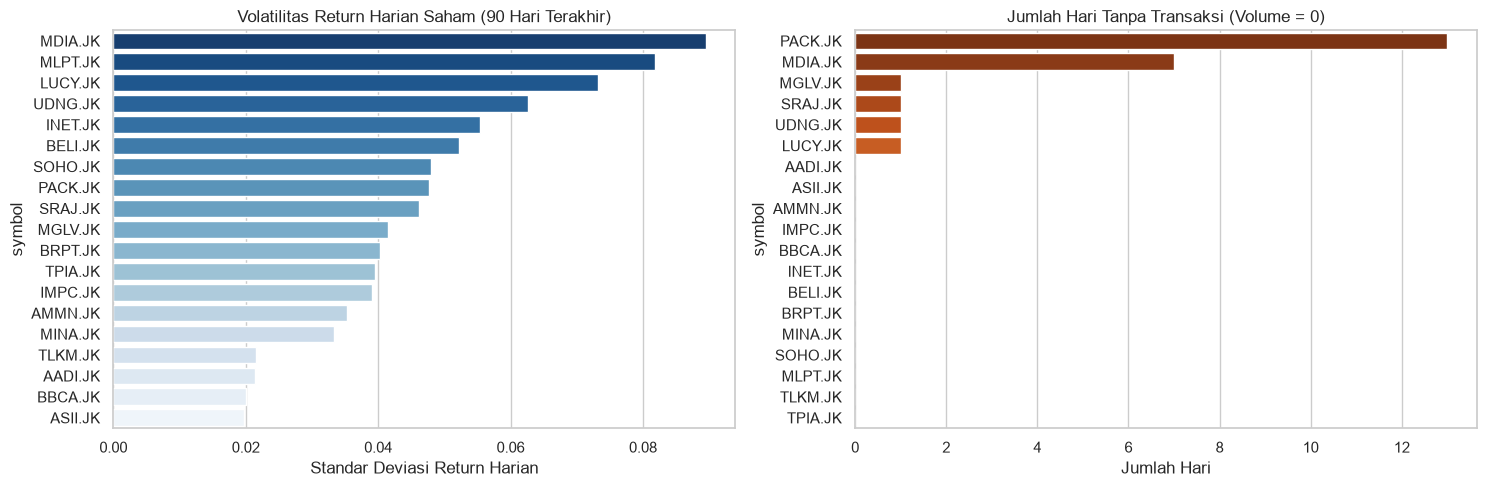

In [5]:
# 3.3 Analisis Likuiditas dan Volatilitas Harga Saham Harian
df_dt["date"] = pd.to_datetime(df_dt["date"])
df_dt["close"] = pd.to_numeric(df_dt["close"], errors="coerce")
df_dt["volume"] = pd.to_numeric(df_dt["volume"], errors="coerce").fillna(0)
df_dt["market_cap"] = pd.to_numeric(df_dt["market_cap"], errors="coerce")

# Hitung return harian dan volatilitas per simbol
df_dt = df_dt.sort_values(["symbol", "date"])
df_dt["daily_return"] = df_dt.groupby("symbol")["close"].pct_change()

liq_summary = df_dt.groupby("symbol").agg(
    total_days=("date", "count"),
    zero_vol_days=("volume", lambda s: (s == 0).sum()),
    at_floor_days=("close", lambda s: (s == 50).sum()),
    avg_volume=("volume", "mean"),
    volatility=("daily_return", "std"),
    min_close=("close", "min"),
    max_close=("close", "max"),
    last_close=("close", "last")
).reset_index()

liq_summary["pct_zero_volume"] = (liq_summary["zero_vol_days"] / liq_summary["total_days"]) * 100

print("=== Ringkasan Likuiditas & Volatilitas (90 Hari Terakhir) ===")
print(liq_summary.sort_values("volatility", ascending=False).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Barplot Volatilitas
sns.barplot(
    data=liq_summary.sort_values("volatility", ascending=False),
    x="volatility",
    y="symbol",
    ax=axes[0],
    palette="Blues_r"
)
axes[0].set_title("Volatilitas Return Harian Saham (90 Hari Terakhir)")
axes[0].set_xlabel("Standar Deviasi Return Harian")

# Barplot Hari Tanpa Transaksi
sns.barplot(
    data=liq_summary.sort_values("zero_vol_days", ascending=False),
    x="zero_vol_days",
    y="symbol",
    ax=axes[1],
    palette="Oranges_r"
)
axes[1].set_title("Jumlah Hari Tanpa Transaksi (Volume = 0)")
axes[1].set_xlabel("Jumlah Hari")

plt.tight_layout()
plt.show()

=== Distribusi Taksonomi Alasan Suspensi ===
event_category
A    457
C    124
B     10
Name: count, dtype: int64


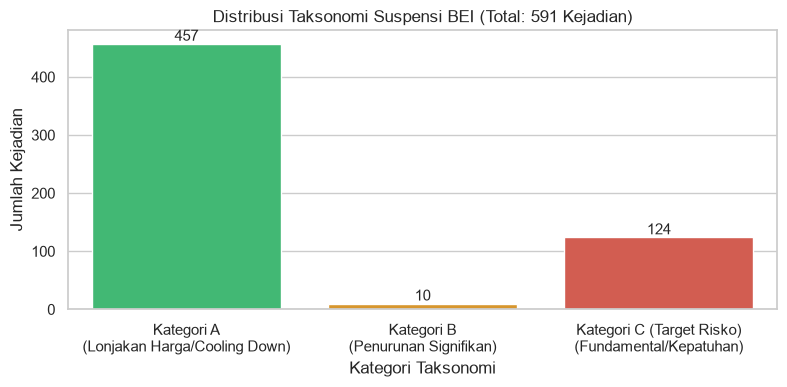


Contoh Alasan Suspensi Kategori C (Risiko Fundamental & Regulasi):
 symbol suspension_date                                                                                                    reason
LCKM.JK      2026-09-10                                           Sehubungan dengan adanya ketidakpastian atas kelangsungan usaha
COAL.JK      2026-08-12                                           Sehubungan dengan adanya ketidakpastian atas kelangsungan usaha
INCF.JK      2026-08-12                                           Sehubungan dengan adanya ketidakpastian atas kelangsungan usaha
ZINC.JK      2026-05-05 Efek Perseroan telah berada dalam papan pemantauan khusus selama lebih dari 1 (satu) tahun berturut-turut
ZINC.JK      2026-04-10 Efek Perseroan telah berada dalam papan pemantauan khusus selama lebih dari 1 (satu) tahun berturut-turut
BIMA.JK      2026-04-09 Efek Perseroan telah berada dalam papan pemantauan khusus selama lebih dari 1 (satu) tahun berturut-turut
POLY.JK      2026-04-0

In [6]:
# 3.4 Taksonomi Alasan Suspensi BEI & Pembentukan Label Positif
df_sus["suspension_date"] = pd.to_datetime(df_sus["suspension_date"])

# Definisi Taksonomi AMBA:
# - Kategori A: Suspensi lonjakan harga / cooling down UMA (perlindungan volatilitas naik)
# - Kategori B: Suspensi penurunan harga kumulatif signifikan
# - Kategori C: Suspensi fundamental / kepatuhan / going concern / kewajiban bursa (LABEL POSITIF TARGET)

def classify_suspension_reason(reason_text: str) -> str:
    if not isinstance(reason_text, str) or not reason_text.strip():
        return "Unknown"
    
    r = reason_text.lower()
    
    # Kategori C: Masalah fundamental, audit, regulasi, kelangsungan usaha
    cat_c_keywords = [
        "suspend more than 6 month",
        "laporan keuangan auditan",
        "kelangsungan usaha",
        "going concern",
        "peraturan bursa",
        "pemantauan khusus selama lebih dari 1",
        "biaya pencatatan",
        "pkpu",
        "pailit",
        "keterlambatan pembayaran",
        "meragukan"
    ]
    for kw in cat_c_keywords:
        if kw in r:
            return "C"
            
    # Kategori B: Penurunan harga kumulatif signifikan
    if "penurunan harga" in r:
        return "B"
        
    # Kategori A: Lonjakan harga kumulatif, cooling down UMA
    if "peningkatan harga" in r or "cooling down" in r or "perlindungan bagi investor" in r or "uma" in r:
        return "A"
        
    return "C" # Default konservatif untuk alasan sanksi lainnya

df_sus["event_category"] = df_sus["reason"].apply(classify_suspension_reason)

print("=== Distribusi Taksonomi Alasan Suspensi ===")
print(df_sus["event_category"].value_counts())

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df_sus, x="event_category", order=["A", "B", "C"], palette=["#2ecc71", "#f39c12", "#e74c3c"], ax=ax)
ax.set_title("Distribusi Taksonomi Suspensi BEI (Total: 591 Kejadian)")
ax.set_xlabel("Kategori Taksonomi")
ax.set_ylabel("Jumlah Kejadian")
ax.set_xticklabels(["Kategori A\n(Lonjakan Harga/Cooling Down)", "Kategori B\n(Penurunan Signifikan)", "Kategori C (Target Risko)\n(Fundamental/Kepatuhan)"])
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="center", xytext=(0, 5), textcoords="offset points")
plt.tight_layout()
plt.show()

# Tampilkan contoh alasan Kategori C
print("\nContoh Alasan Suspensi Kategori C (Risiko Fundamental & Regulasi):")
print(df_sus[df_sus["event_category"] == "C"][["symbol", "suspension_date", "reason"]].head(8).to_string(index=False))

---
## 4. Point-in-Time Temporal Feature Engineering

Untuk memodelkan probabilitas suspensi dalam horizon 90 hari ($is\_event\_90d$), kita menerapkan arsitektur **Point-in-Time (PIT)**:
1. **Titik Potong ($T_0 = as\_of\_date$)**: Seluruh fitur hanya dihitung dari data yang tersedia pada atau sebelum $T_0$.
2. **Jendela Fitur Transaksi**: Rentang $[T_0 - 90\text{ hari}, T_0]$.
3. **Laporan Keuangan Terakhir**: Mengambil laporan dengan $report\_date \le T_0$.
4. **Target Label ($is\_event\_90d$)**: Bernilai 1 jika terdapat kejadian suspensi **Kategori C** dalam interval $(T_0, T_0 + 90\text{ hari}]$.
5. **Kontrol Temporal**: 
   - `feature_max_source_date`: Tanggal terbaru data mentah yang dipakai pada baris tersebut (pencegah look-ahead bias).
   - `already_flagged`: Bernilai 1 jika emiten sudah menyandang suspensi aktif pada $T_0$.

In [7]:
# 4.1 Modul Perhitungan Fitur Temporal Per Emiten pada Titik Potong as_of_date

def build_temporal_features_for_ticker(
    symbol: str,
    as_of_date: date,
    df_qf_all: pd.DataFrame,
    df_dt_all: pd.DataFrame,
    df_ff_all: pd.DataFrame,
    df_co_all: pd.DataFrame,
    df_sus_all: pd.DataFrame,
    sertakan_free_float: bool = True
) -> dict:
    """
    Membangun satu baris data lengkap (Identitas, Mentah, Turunan, dan Target)
    untuk satu symbol pada as_of_date dengan perlindungan temporal data leakage.
    """
    as_of_dt = pd.to_datetime(as_of_date)
    window_90d_start = as_of_dt - pd.Timedelta(days=90)
    window_30d_start = as_of_dt - pd.Timedelta(days=30)
    
    # 1. Identitas Emiten
    ov = df_co_all[df_co_all["symbol"] == symbol]
    sector = ov["sector"].iloc[0] if not ov.empty else None
    sub_sector = ov["sub_sector"].iloc[0] if not ov.empty else None
    board = ov["board"].iloc[0] if not ov.empty else None
    company_name = ov["company_name"].iloc[0] if not ov.empty else None
    
    # 2. Filter Laporan Keuangan (Point-in-Time: report_date <= as_of_date)
    qf = df_qf_all[(df_qf_all["symbol"] == symbol) & (df_qf_all["report_date"] <= as_of_dt)]
    qf = qf.sort_values("report_date")
    
    source_dates = []
    
    # Nilai mentah fundamental
    if not qf.empty:
        latest_qf = qf.iloc[-1]
        last_report_date = latest_qf["report_date"]
        source_dates.append(last_report_date.date())
        
        raw_revenue = latest_qf["revenue"]
        raw_earnings = latest_qf["earnings"]
        raw_total_equity = latest_qf["total_equity"]
        raw_total_liabilities = latest_qf["total_liabilities"]
        raw_total_assets = latest_qf["total_assets"]
        raw_total_debt = latest_qf["total_debt"]
        raw_operating_cash_flow = latest_qf["operating_cash_flow"]
        raw_free_cash_flow = latest_qf["free_cash_flow"]
        
        # Indikator Kepatuhan (Section 3.1)
        lapor_jarak_hari = (as_of_date - last_report_date.date()).days
        lapor_terlambat = int(lapor_jarak_hari > config.LAPOR_TENGGAT_HARI)
        
        # Indikator Kesehatan Finansial (Section 3.2)
        tanpa_pendapatan = int(raw_revenue <= config.REVENUE_MENDEKATI_NOL) if pd.notna(raw_revenue) else None
        ekuitas_negatif = int(raw_total_equity < 0) if pd.notna(raw_total_equity) else None
        utang_terhadap_aset = (float(raw_total_liabilities) / float(raw_total_assets)) if (pd.notna(raw_total_liabilities) and pd.notna(raw_total_assets) and raw_total_assets != 0) else None
        
        # Hitung streak OCF negatif berturut-turut
        ocf_list = qf["operating_cash_flow"].dropna().tolist()
        streak = 0
        for v in reversed(ocf_list):
            if v < 0:
                streak += 1
            else:
                break
        ako_negatif_berturut = streak
    else:
        last_report_date = None
        raw_revenue = raw_earnings = raw_total_equity = raw_total_liabilities = None
        raw_total_assets = raw_total_debt = raw_operating_cash_flow = raw_free_cash_flow = None
        lapor_jarak_hari = lapor_terlambat = tanpa_pendapatan = ekuitas_negatif = utang_terhadap_aset = ako_negatif_berturut = None
        
    # 3. Filter Transaksi Pasar (Point-in-Time: date <= as_of_date)
    dt = df_dt_all[(df_dt_all["symbol"] == symbol) & (df_dt_all["date"] <= as_of_dt)]
    dt = dt.sort_values("date")
    
    dt_90d = dt[(dt["date"] > window_90d_start) & (dt["date"] <= as_of_dt)]
    dt_30d = dt[(dt["date"] > window_30d_start) & (dt["date"] <= as_of_dt)]
    
    if not dt_90d.empty:
        latest_dt = dt_90d.iloc[-1]
        source_dates.append(latest_dt["date"].date())
        raw_close = latest_dt["close"]
        raw_volume = latest_dt["volume"]
        raw_market_cap = latest_dt["market_cap"]
        
        # Indikator Likuiditas & Perilaku Harga (Section 3.3)
        hari_tanpa_transaksi_90d = int((dt_90d["volume"] == 0).sum())
        hari_di_batas_bawah_90d = int((dt_90d["close"] == config.HARGA_BATAS_BAWAH).sum())
        
        avg_vol_90 = dt_90d["volume"].mean()
        avg_vol_30 = dt_30d["volume"].mean() if not dt_30d.empty else None
        rasio_volume_30_90 = (float(avg_vol_30) / float(avg_vol_90)) if (avg_vol_30 is not None and avg_vol_90 and avg_vol_90 > 0) else None
        
        close_tertinggi_90d = dt_90d["close"].max()
        turun_dari_puncak_90d = float((close_tertinggi_90d - raw_close) / close_tertinggi_90d) if (pd.notna(close_tertinggi_90d) and close_tertinggi_90d > 0 and pd.notna(raw_close)) else None
        
        returns = dt_90d["close"].pct_change().dropna()
        volatilitas_90d = float(returns.std()) if len(returns) >= 2 else None
    else:
        raw_close = raw_volume = raw_market_cap = None
        hari_tanpa_transaksi_90d = hari_di_batas_bawah_90d = rasio_volume_30_90 = turun_dari_puncak_90d = volatilitas_90d = None
        
    # 4. Struktur Kepemilikan (Section 2.3 & 3.4)
    ff = df_ff_all[(df_ff_all["symbol"] == symbol) & (df_ff_all["snapshot_date"] <= as_of_date.isoformat())]
    if sertakan_free_float and not ff.empty:
        latest_ff = ff.sort_values("snapshot_date").iloc[-1]
        raw_free_float = float(latest_ff["free_float"]) if pd.notna(latest_ff["free_float"]) else None
        free_float_rendah = int(raw_free_float < (config.FREE_FLOAT_RENDAH_AMBANG_PERSEN / 100.0)) if raw_free_float is not None else None
    else:
        raw_free_float = None
        free_float_rendah = None
        
    # 5. Label Target & Status Suspensi
    # Cek apakah sudah disuspensi pada atau sebelum as_of_date (already_flagged)
    prior_sus = df_sus_all[(df_sus_all["symbol"] == symbol) & (df_sus_all["suspension_date"] <= as_of_dt)]
    already_flagged = int(not prior_sus.empty and (board == "Watchlist" or (as_of_dt - prior_sus["suspension_date"].max()).days <= 180))
    
    # Cek kejadian suspensi Kategori C dalam jendela ke depan [as_of_date + 1, as_of_date + 90 hari]
    window_90d_future = as_of_dt + pd.Timedelta(days=90)
    future_sus = df_sus_all[
        (df_sus_all["symbol"] == symbol) & 
        (df_sus_all["suspension_date"] > as_of_dt) & 
        (df_sus_all["suspension_date"] <= window_90d_future)
    ]
    
    future_sus_c = future_sus[future_sus["event_category"] == "C"]
    if not future_sus_c.empty:
        is_event_90d = 1
        event_date = future_sus_c.iloc[0]["suspension_date"].strftime("%Y-%m-%d")
        event_category = "C"
    elif not future_sus.empty:
        is_event_90d = 0  # Suspensi terjadi tapi kategori A atau B (bukan masalah fundamental)
        event_date = future_sus.iloc[0]["suspension_date"].strftime("%Y-%m-%d")
        event_category = future_sus.iloc[0]["event_category"]
    else:
        is_event_90d = 0
        event_date = None
        event_category = None
        
    # Tanggal ketersediaan fitur terbaru
    feature_max_source_date = max(source_dates) if source_dates else None
    
    # Data complete flag
    inti = [lapor_jarak_hari, utang_terhadap_aset, hari_tanpa_transaksi_90d, volatilitas_90d]
    data_complete = int(all(v is not None for v in inti))
    
    return {
        # Section 1: Identitas & Label
        "symbol": symbol,
        "company_name": company_name,
        "as_of_date": as_of_date.isoformat(),
        "sector": sector,
        "sub_sector": sub_sector,
        "board": board,
        "is_event_90d": is_event_90d,
        "event_date": event_date,
        "event_category": event_category,
        "already_flagged": already_flagged,
        "data_complete": data_complete,
        "feature_max_source_date": feature_max_source_date.isoformat() if feature_max_source_date else None,
        
        # Section 2: Variabel Mentah
        "raw_revenue": raw_revenue,
        "raw_earnings": raw_earnings,
        "raw_total_equity": raw_total_equity,
        "raw_total_liabilities": raw_total_liabilities,
        "raw_total_assets": raw_total_assets,
        "raw_total_debt": raw_total_debt,
        "raw_operating_cash_flow": raw_operating_cash_flow,
        "raw_free_cash_flow": raw_free_cash_flow,
        "raw_report_date": last_report_date.strftime("%Y-%m-%d") if last_report_date is not None else None,
        "raw_close": raw_close,
        "raw_volume": raw_volume,
        "raw_market_cap": raw_market_cap,
        "raw_free_float": raw_free_float,
        
        # Section 3: Indikator Risiko Turunan
        "lapor_jarak_hari": lapor_jarak_hari,
        "lapor_terlambat": lapor_terlambat,
        "tanpa_pendapatan": tanpa_pendapatan,
        "ekuitas_negatif": ekuitas_negatif,
        "utang_terhadap_aset": utang_terhadap_aset,
        "ako_negatif_berturut": ako_negatif_berturut,
        "hari_tanpa_transaksi_90d": hari_tanpa_transaksi_90d,
        "rasio_volume_30_90": rasio_volume_30_90,
        "hari_di_batas_bawah_90d": hari_di_batas_bawah_90d,
        "turun_dari_puncak_90d": turun_dari_puncak_90d,
        "volatilitas_90d": volatilitas_90d,
        "free_float_rendah": free_float_rendah
    }

print("Fungsi build_temporal_features_for_ticker siap digunakan.")

Fungsi build_temporal_features_for_ticker siap digunakan.


In [8]:
# 4.2 Membangun Dataset Multi-Snapshot Lintas Waktu (Temporal Modeling Dataset)
# Kita membuat observasi pada beberapa titik potong (as_of_date):
# - Snapshot bulanan/bi-weekly: 2026-07-15, 2026-07-31, 2026-08-15, 2026-08-31, 2026-09-11, 2026-09-16

snapshot_dates = [
    date(2026, 7, 15),
    date(2026, 7, 31),
    date(2026, 8, 15),
    date(2026, 8, 31),
    date(2026, 9, 11),
    date(2026, 9, 16)
]

all_symbols = df_co["symbol"].unique().tolist()
rows = []

print(f"Membangun fitur temporal untuk {len(all_symbols)} emiten x {len(snapshot_dates)} snapshot dates...")
for as_of in snapshot_dates:
    for sym in all_symbols:
        row = build_temporal_features_for_ticker(
            symbol=sym,
            as_of_date=as_of,
            df_qf_all=df_qf,
            df_dt_all=df_dt,
            df_ff_all=df_ff,
            df_co_all=df_co,
            df_sus_all=df_sus,
            sertakan_free_float=True
        )
        rows.append(row)

df_unified = pd.DataFrame(rows)
print(f"Dataset berhasil disintesis: {df_unified.shape[0]} baris x {df_unified.shape[1]} kolom.")

Membangun fitur temporal untuk 19 emiten x 6 snapshot dates...


Dataset berhasil disintesis: 114 baris x 37 kolom.


In [9]:
# 4.3 Inspeksi Unified DataFrame
print("=== Struktur Kolom Dataset ===")
print(df_unified.info())

print("\n=== Sampel 5 Baris Teratas ===")
display(df_unified.head())

print("\n=== Ringkasan Nilai Null (Missing Values) ===")
nulls = df_unified.isnull().sum()
print(nulls[nulls > 0])

=== Struktur Kolom Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   symbol                    114 non-null    str    
 1   company_name              114 non-null    str    
 2   as_of_date                114 non-null    str    
 3   sector                    114 non-null    str    
 4   sub_sector                114 non-null    str    
 5   board                     114 non-null    str    
 6   is_event_90d              114 non-null    int64  
 7   event_date                16 non-null     str    
 8   event_category            16 non-null     str    
 9   already_flagged           114 non-null    int64  
 10  data_complete             114 non-null    int64  
 11  feature_max_source_date   114 non-null    str    
 12  raw_revenue               90 non-null     float64
 13  raw_earnings              90 non-null     flo

,symbol,company_name,as_of_date,sector,sub_sector,board,is_event_90d,event_date,event_category,already_flagged,...,tanpa_pendapatan,ekuitas_negatif,utang_terhadap_aset,ako_negatif_berturut,hari_tanpa_transaksi_90d,rasio_volume_30_90,hari_di_batas_bawah_90d,turun_dari_puncak_90d,volatilitas_90d,free_float_rendah
0,BBCA.JK,PT Bank Central Asia Tbk.,2026-07-15,Financials,Banks,Main,0,NaN,NaN,0,...,0.0,0,0.830741,1,0,0.942878,0,0.027778,0.027681,NaN
1,TLKM.JK,PT Telkom Indonesia (Persero) Tbk,2026-07-15,Infrastructures,Telecommunication,Main,0,NaN,NaN,0,...,0.0,0,0.555085,0,0,0.998681,0,0.148649,0.026685,NaN
2,ASII.JK,Astra International Tbk,2026-07-15,Industrials,Multi-sector Holdings,Main,0,NaN,NaN,0,...,0.0,0,0.436668,0,0,0.975156,0,0.016227,0.024129,NaN
3,AMMN.JK,PT Amman Mineral Internasional Tbk.,2026-07-15,Basic Materials,Basic Materials,Main,0,NaN,NaN,0,...,0.0,0,0.601625,0,0,0.932924,0,0.060000,0.045210,NaN
4,IMPC.JK,PT Impack Pratama Industri Tbk,2026-07-15,Industrials,Industrial Goods,Main,0,NaN,NaN,0,...,0.0,0,0.359018,0,0,0.943418,0,0.184874,0.037246,NaN



=== Ringkasan Nilai Null (Missing Values) ===
event_date                 98
event_category             98
raw_revenue                24
raw_earnings               24
raw_total_debt             18
raw_operating_cash_flow    24
raw_free_cash_flow         24
raw_free_float             76
tanpa_pendapatan           24
free_float_rendah          76
dtype: int64


---
## 5. Analisis Hubungan Fitur & Kesiapan Pemodelan

Pada bagian ini kita menganalisis:
- Korelasi antar indikator risiko
- Korelasi fitur terhadap label target `is_event_90d`
- Verifikasi bahwa tidak ada kebocoran temporal (`feature_max_source_date <= as_of_date`)
- Pemisahan sampel berdasarkan status `already_flagged`

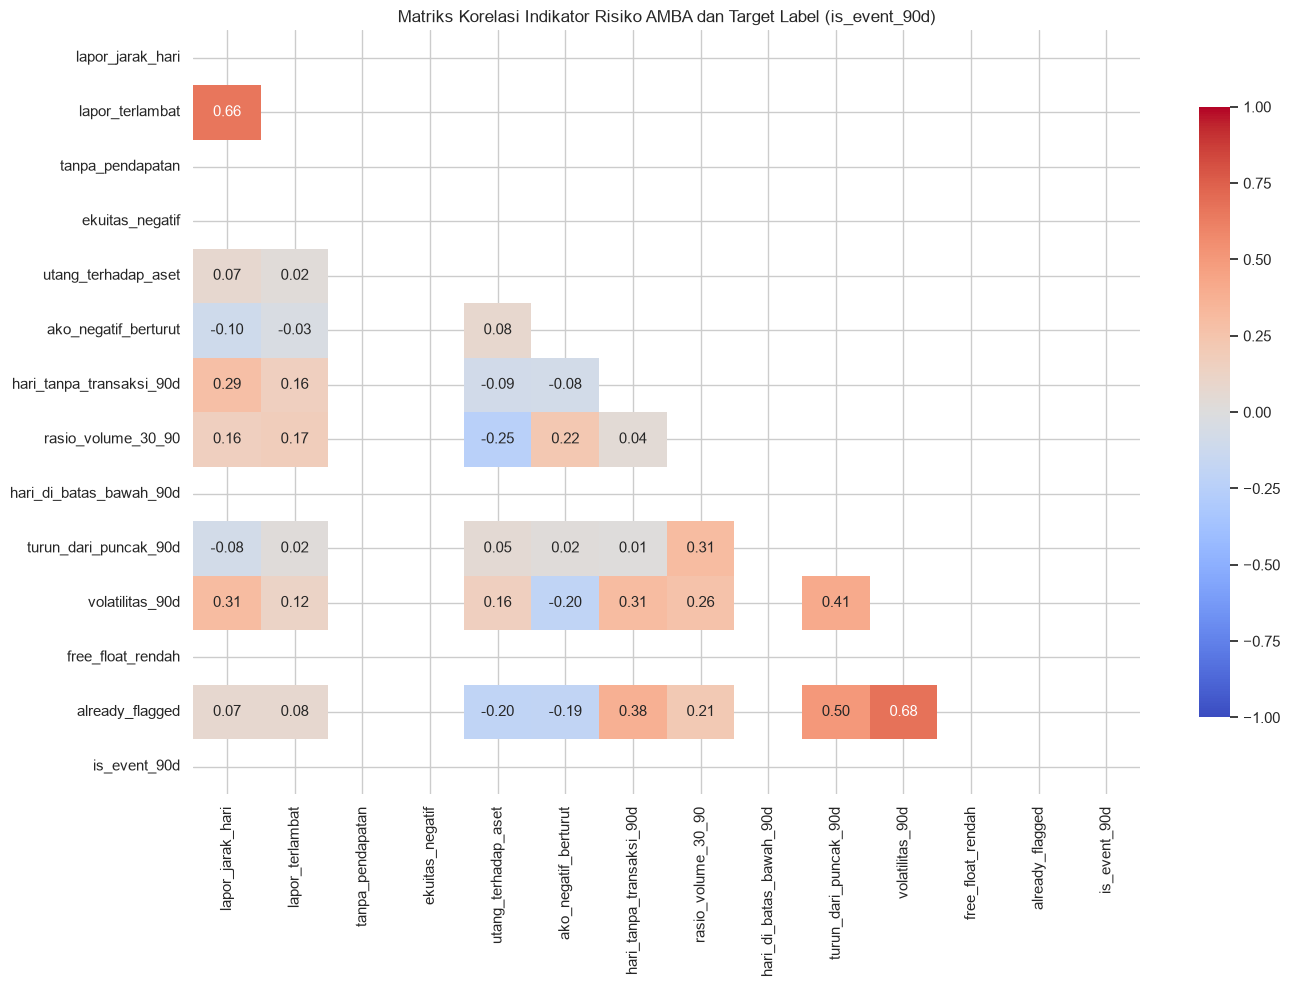

In [10]:
# 5.1 Korelasi Matriks Indikator Risiko Turunan
feature_cols = [
    "lapor_jarak_hari", "lapor_terlambat", "tanpa_pendapatan", "ekuitas_negatif",
    "utang_terhadap_aset", "ako_negatif_berturut", "hari_tanpa_transaksi_90d",
    "rasio_volume_30_90", "hari_di_batas_bawah_90d", "turun_dari_puncak_90d",
    "volatilitas_90d", "free_float_rendah", "already_flagged", "is_event_90d"
]

corr = df_unified[feature_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={"shrink": .8}, vmin=-1, vmax=1)
plt.title("Matriks Korelasi Indikator Risiko AMBA dan Target Label (is_event_90d)")
plt.tight_layout()
plt.show()

In [11]:
# 5.2 Pemeriksaan Integritas Temporal (Anti Data Leakage Check)
df_unified["as_of_date_dt"] = pd.to_datetime(df_unified["as_of_date"])
df_unified["max_source_dt"] = pd.to_datetime(df_unified["feature_max_source_date"])

leakage_count = (df_unified["max_source_dt"] > df_unified["as_of_date_dt"]).sum()
print("=== Hasil Audit Kebocoran Temporal ===")
print(f"Jumlah baris dengan source date > as_of_date: {leakage_count}")
if leakage_count == 0:
    print("[PASS] Tidak ditemukan kebocoran data masa depan ke fitur masa lalu.")
else:
    print("[FAIL] Peringatan: Terdapat potensi look-ahead bias!")

print("\nDistribusi Target is_event_90d:")
print(df_unified["is_event_90d"].value_counts(dropna=False))

print("\nDistribusi Status already_flagged:")
print(df_unified["already_flagged"].value_counts(dropna=False))

=== Hasil Audit Kebocoran Temporal ===
Jumlah baris dengan source date > as_of_date: 0
[PASS] Tidak ditemukan kebocoran data masa depan ke fitur masa lalu.

Distribusi Target is_event_90d:
is_event_90d
0    114
Name: count, dtype: int64

Distribusi Status already_flagged:
already_flagged
0    79
1    35
Name: count, dtype: int64


In [12]:
# 6. Ekspor Dataset Siap Model
output_dir = os.path.join(project_root, "output")
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, "dataset_modeling_ambang.csv")
parquet_path = os.path.join(output_dir, "dataset_modeling_ambang.parquet")

# Hapus kolom bantu datetime
export_df = df_unified.drop(columns=["as_of_date_dt", "max_source_dt"], errors="ignore")

export_df.to_csv(csv_path, index=False)
try:
    export_df.to_parquet(parquet_path, index=False)
    print(f"2. Parquet : {parquet_path} ({os.path.getsize(parquet_path):,} bytes)")
except Exception as e:
    print(f"2. Parquet export opsional dilewati: {e}")

print(f"1. CSV     : {csv_path} ({os.path.getsize(csv_path):,} bytes)")

2. Parquet : C:\Users\Yosua Triantara\Documents\Project\Ambang\output\dataset_modeling_ambang.parquet (31,807 bytes)
1. CSV     : C:\Users\Yosua Triantara\Documents\Project\Ambang\output\dataset_modeling_ambang.csv (40,936 bytes)


---
## 7. Kesimpulan dan Langkah Pemodelan Selanjutnya

1. **Kelengkapan Data**:
   - Seluruh variabel mentah (Kuartalan, Transaksi Harian, Free Float, Overview, dan Suspensi) dari Sectors API telah lengkap di database.
   - 11 Indikator risiko turunan berhasil dihitung sesuai rumus resmi di `AMBA-kamus-variabel.md`.
2. **Karakteristik Temporal**:
   - Struktur dataset disusun berbasis point-in-time ($as\_of\_date$), memisahkan jendela fitur ($T_{-90} \to T_0$) dan jendela prediksi label ($T_0 \to T_{+90}$).
   - Kebocoran data dicegah secara ketat (`max_source_date <= as_of_date`).
   - Emiten yang sudah berstatus suspensi atau berada di Watchlist dipisahkan menggunakan flag `already_flagged`.
3. **Rekomendasi Pemodelan**:
   - **Baseline Model**: Regresi Logistik terstandardisasi untuk kemudahan interpretasi koefisien (bobot kontribusi indikator).
   - **Model Non-Linear**: LightGBM atau Random Forest dengan penanganan ketimpangan kelas (class imbalance).
   - **Metrik Evaluasi**: Menggunakan `Precision@20` dan `Recall@90h` sesuai Bagian 5 Kamus Variabel, bukan sekadar akurasi.